In [177]:
include("evolMPDO.jl");
include("IsingED.jl");

using GLM
using DataFrames
using LaTeXStrings
using Plots

### Pure state Ising benchmark

In [ ]:
function mid_fidelity_mps(N::Int)
    
    h = 1.0;
    psiMPS, psiMPS_exc1, psiMPS_exc2 = Ising_GS_DMRG(N,h,true,nsweeps=20, max_bd=200);

    A_GS = myMPS(MPS_to_array(psiMPS));
    A_exc1 = myMPS(MPS_to_array(psiMPS_exc1));
    A_exc2 = myMPS(MPS_to_array(psiMPS_exc2));

    A_tot = [A_GS, A_exc1, A_exc2]

    p1 = 1.0;  # maximal
    Sx = [0 1; 1 0]
    Sz = [1 0; 0 -1]

    i = 1
    j = Int(N/4)+1   # fix the ratio to be 1/4

    F0_mps_tot = zeros(eltype(A_GS.TensorList[1]), 3)

    for ii in 1:3
        A = A_tot[ii]
        # F0_mps_tot[ii] = fidelity_op_mps(A, Sz, Sz, i, j)
        F0_mps_tot[ii] = fidelity_op_mps(A, Sx, Sx, i, j)
    end

    return F0_mps_tot

end

mid_fidelity_mps (generic function with 1 method)

In [144]:
N_tot = collect(8:4:12)
fidelity_array_mps = zeros(Float64, length(N_tot), 3)

for ii in 1:length(N_tot)
    tmp = mid_fidelity_mps(N_tot[ii])
    fidelity_array_mps[ii,:] = tmp
end

After sweep 1 energy=-10.21781901258302  maxlinkdim=18 maxerr=7.36E-09 time=0.012
After sweep 2 energy=-10.247782831269468  maxlinkdim=16 maxerr=8.49E-11 time=0.009
After sweep 3 energy=-10.251641060338677  maxlinkdim=16 maxerr=7.52E-11 time=0.009
After sweep 4 energy=-10.251661778538073  maxlinkdim=14 maxerr=6.60E-11 time=0.007
After sweep 5 energy=-10.251661789877893  maxlinkdim=13 maxerr=7.03E-11 time=0.017
After sweep 6 energy=-10.251661789984794  maxlinkdim=13 maxerr=6.43E-11 time=0.007
After sweep 7 energy=-10.251661789984844  maxlinkdim=13 maxerr=6.42E-11 time=0.007
After sweep 8 energy=-10.251661789984837  maxlinkdim=13 maxerr=6.42E-11 time=0.006
After sweep 9 energy=-10.251661789984828  maxlinkdim=13 maxerr=6.42E-11 time=0.017
After sweep 10 energy=-10.251661789984842  maxlinkdim=13 maxerr=6.42E-11 time=0.021
After sweep 11 energy=-10.251661789984835  maxlinkdim=13 maxerr=6.42E-11 time=0.009
After sweep 12 energy=-10.25166178998483  maxlinkdim=13 maxerr=6.42E-11 time=0.007
Aft

In [146]:
fidelity_array_mps

2×3 Matrix{Float64}:
 0.554694  0.724742  0.266373
 0.502258  0.656232  0.246776

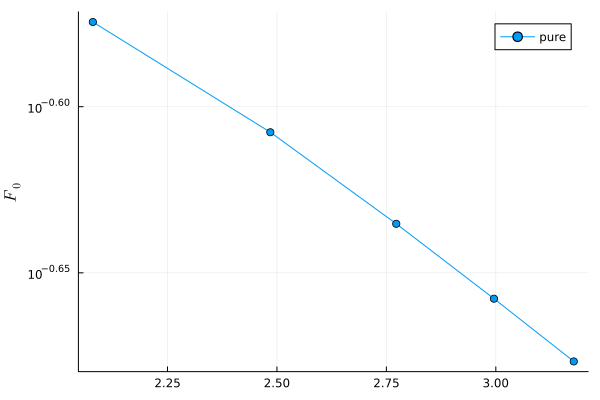

In [142]:
x0 = N_tot
y0 = fidelity_array_mps[:,3]
entp = length(x0)
startp = 1
x0p = x0  #PBC
# x0p = x0
plot(log.(x0p[startp:entp]), y0[startp:entp], yscale=:log10, marker = :circle, label="pure", xlabel = "", ylabel = L"$F_0$")
# plot!(log.(x0p[startp:entp]), F0_array[startp:entp], yscale=:log10 , marker = :circle, label="mixed")

-0.10729054787268619


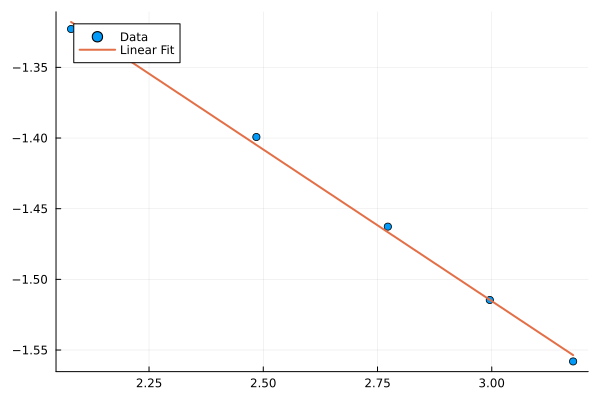

In [143]:
intp = 1
entp = length(x0)
x = log.(x0p[startp:1:entp])
y = log.(y0[startp:1:entp])

# Step 1: Put data into a DataFrame
df = DataFrame(x = x, y = y)

# Step 2: Fit linear model y ~ x
model = lm(@formula(y ~ x), df)

# Step 3: Get predicted y values
yp = predict(model)
println(coef(model)[2]/2)  # Delta

# Step 4: Plot original data and fitted line
scatter(x, y, label = "Data", legend = :topleft)
plot!(x, yp, label = "Linear Fit", lw=2)

In [ ]:
# PBC
0.25
0.25
2.25

### Mixed Exact

In [ ]:
function mid_fidelity_exact(N::Int)
    # only for small system sizes

    h = 1.0;
    psiMPS, psiMPS_exc1, psiMPS_exc2 = Ising_GS_DMRG(N,h,true,nsweeps=20, max_bd=200);

    A_GS = myMPS(MPS_to_array(psiMPS));
    A_exc1 = myMPS(MPS_to_array(psiMPS_exc1));
    A_exc2 = myMPS(MPS_to_array(psiMPS_exc2));

    A_tot = [A_GS, A_exc1, A_exc2]

    p1 = 1.0;  # maximal
    Sx = [0 1; 1 0]
    Sz = [1 0; 0 -1]

    i = 1
    j = Int(N/4)+1  # fix the ratio to be 1/4

    F0_tot = zeros(eltype(A_GS.TensorList[1]), 3)

    for ii in 1:3
        A = A_tot[ii]
        Ws1 = Array{Float64,3}[purified_dephasing_channel(p1,[0,0,1]) for _ in 1:N]
        M1 = add_noise_MPS(A, Ws1)

        F0_tot[ii] = fidelity_op(M1, Sx, Sx, i, j) 
    end

    return F0_tot
end

mid_fidelity_exact (generic function with 1 method)

In [178]:
N_tot = collect(8:4:12)
fidelity_array = zeros(Float64, length(N_tot), 3)

for ii in 1:length(N_tot)
    tmp = mid_fidelity_exact(N_tot[ii])
    fidelity_array[ii,:] = tmp
end

After sweep 1 energy=-10.251024520787741  maxlinkdim=16 maxerr=3.10E-09 time=0.012
After sweep 2 energy=-10.25166123145197  maxlinkdim=16 maxerr=9.63E-11 time=0.086
After sweep 3 energy=-10.251661788882515  maxlinkdim=13 maxerr=7.92E-11 time=0.019
After sweep 4 energy=-10.251661789984514  maxlinkdim=13 maxerr=6.60E-11 time=0.019
After sweep 5 energy=-10.25166178998485  maxlinkdim=13 maxerr=6.60E-11 time=0.011
After sweep 6 energy=-10.25166178998484  maxlinkdim=13 maxerr=6.42E-11 time=0.015
After sweep 7 energy=-10.251661789984823  maxlinkdim=13 maxerr=6.42E-11 time=0.011
After sweep 8 energy=-10.251661789984835  maxlinkdim=13 maxerr=6.42E-11 time=0.007
After sweep 9 energy=-10.25166178998483  maxlinkdim=13 maxerr=6.42E-11 time=0.461
After sweep 10 energy=-10.251661789984835  maxlinkdim=13 maxerr=6.42E-11 time=0.016
After sweep 11 energy=-10.251661789984833  maxlinkdim=13 maxerr=6.42E-11 time=0.014
After sweep 12 energy=-10.25166178998484  maxlinkdim=13 maxerr=6.42E-11 time=0.012
After 

In [179]:
fidelity_array

2×3 Matrix{Float64}:
 0.554694  0.724742  0.589597
 0.502258  0.656232  0.513381

### Mixed Optimization

In [153]:
function M1_M2(N::Int)

    h = 1.0;
    psiMPS, psiMPS_exc1, psiMPS_exc2 = Ising_GS_DMRG(N,h,true,nsweeps=20, max_bd=200);

    A_GS = myMPS(MPS_to_array(psiMPS));
    A_exc1 = myMPS(MPS_to_array(psiMPS_exc1));
    A_exc2 = myMPS(MPS_to_array(psiMPS_exc2));

    A_tot = [A_GS, A_exc1, A_exc2]

    p1 = 1.0;  # maximal
    Sx = [0 1; 1 0]
    Sz = [1 0; 0 -1]

    i = 1
    j = Int(N/4)+1  # fix the ratio to be 1/4

    M1_tot = []
    M2_tot = []

    for ii in 1:3
        A = A_tot[ii]
        Ws1 = Array{Float64,3}[purified_dephasing_channel(p1,[0,0,1]) for _ in 1:N]
        M1 = add_noise_MPS(A, Ws1)
        M2 = add_CP(add_CP(M1, Sx, i), Sx, j)

        push!(M1_tot, M1)
        push!(M2_tot, M2)
    end

    return M1_tot, M2_tot
end

M1_M2 (generic function with 1 method)

In [154]:
N_tot = collect(8:4:12)
M1_array = []
M2_array = [] # adding noise and X operators

for ii in 1:length(N_tot)
    M1_tot, M2_tot = M1_M2(N_tot[ii])
    push!(M1_array, M1_tot)
    push!(M2_array, M2_tot)
end

After sweep 1 energy=-10.181616811742666  maxlinkdim=18 maxerr=7.64E-10 time=0.025
After sweep 2 energy=-10.242245630732883  maxlinkdim=16 maxerr=8.65E-11 time=0.020
After sweep 3 energy=-10.251505293269307  maxlinkdim=15 maxerr=9.59E-11 time=0.018
After sweep 4 energy=-10.251661676133587  maxlinkdim=15 maxerr=6.62E-11 time=0.013
After sweep 5 energy=-10.251661789663768  maxlinkdim=13 maxerr=6.91E-11 time=0.007
After sweep 6 energy=-10.251661789984748  maxlinkdim=13 maxerr=6.45E-11 time=0.016
After sweep 7 energy=-10.251661789984839  maxlinkdim=13 maxerr=6.42E-11 time=0.010
After sweep 8 energy=-10.25166178998484  maxlinkdim=13 maxerr=6.42E-11 time=0.006
After sweep 9 energy=-10.251661789984832  maxlinkdim=13 maxerr=6.42E-11 time=0.014
After sweep 10 energy=-10.251661789984832  maxlinkdim=13 maxerr=6.42E-11 time=0.013
After sweep 11 energy=-10.251661789984828  maxlinkdim=13 maxerr=6.42E-11 time=0.018
After sweep 12 energy=-10.251661789984844  maxlinkdim=13 maxerr=6.42E-11 time=0.016
Af

In [169]:
size(M1_array[2])

(3,)

In [181]:
i_N = 2
i_exc = 3
M1 = M1_array[i_N][i_exc]
M2 = M2_array[i_N][i_exc]

da = 2
M1_acl = add_ancillas(M1; da=da)
M2_acl = add_ancillas(M2; da=da);

d = 2*da   
dt = 1.0;
Us = random_U(d, dt, length(M1))

ovs = optimize_overlap_onefloor_sweep(complex(M1_acl),complex(M2_acl),Us,100,verbose=1,max_bd = 256); ## Ancilla version

Initial overlap: 2.1333019283792186e-34
Sweep: 1
New overlap: 0.3343776871382922
Max bond dim: 256
New overlap: 0.36380754720863134
Max bond dim: 256
Sweep: 2
New overlap: 0.37063831556133287
Max bond dim: 256
New overlap: 0.372730154008716
Max bond dim: 256
Sweep: 3
New overlap: 0.37365886532699605
Max bond dim: 256
New overlap: 0.37421489911013
Max bond dim: 255
Sweep: 4
New overlap: 0.374629320332664
Max bond dim: 251
New overlap: 0.37498851863837485
Max bond dim: 241
Sweep: 5
New overlap: 0.3753332318128932
Max bond dim: 242
New overlap: 0.37568805047412024
Max bond dim: 236
Sweep: 6
New overlap: 0.37607133718929653
Max bond dim: 238
New overlap: 0.3764988888202755
Max bond dim: 233
Sweep: 7
New overlap: 0.3769850112995485
Max bond dim: 235
New overlap: 0.37754267696246996
Max bond dim: 231
Sweep: 8
New overlap: 0.37818276299759146
Max bond dim: 233
New overlap: 0.3789132491263762
Max bond dim: 229
Sweep: 9
New overlap: 0.37973794291699847
Max bond dim: 231
New overlap: 0.380656133

In [159]:
fidelity_array

2×3 Matrix{Float64}:
 0.554694  0.724742  0.589597
 0.502258  0.656232  0.513381

In [168]:
d = 2   
dt = 1.0;
Us = random_U(d, dt, N)
ovs2 = optimize_overlap_onefloor_sweep(complex(M1), complex(M2),Us,100,verbose=1);

Initial overlap: 4.4771192993927767e-35
Sweep: 1
New overlap: 0.3462372939404625
Max bond dim: 57
New overlap: 0.40634294660190384
Max bond dim: 55
Sweep: 2
New overlap: 0.4151341072466769
Max bond dim: 53
New overlap: 0.4187346678270544
Max bond dim: 52
Sweep: 3
New overlap: 0.4208770245874772
Max bond dim: 52
New overlap: 0.4224025564651361
Max bond dim: 51
Sweep: 4
New overlap: 0.4236112710051846
Max bond dim: 51
New overlap: 0.42466457096559523
Max bond dim: 50
Sweep: 5
New overlap: 0.4256325535284827
Max bond dim: 50
New overlap: 0.42656631107758936
Max bond dim: 50
Sweep: 6
New overlap: 0.4274833243677887
Max bond dim: 50
New overlap: 0.42840967121871837
Max bond dim: 49
Sweep: 7
New overlap: 0.42936839555275597
Max bond dim: 49
New overlap: 0.4304204509859347
Max bond dim: 48
Sweep: 8
New overlap: 0.4316961892349804
Max bond dim: 48
New overlap: 0.43353132775319225
Max bond dim: 47
Sweep: 9
New overlap: 0.4367614718940335
Max bond dim: 47
New overlap: 0.4428046487409166
Max bond